<a href="https://colab.research.google.com/github/fcoliveira-utfpr/aquacrop_ml/blob/main/02_bh_cultura_milho.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Início - Bibliotecas**
---

In [1]:
#importando bibliotecas
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import json
import requests
import os
import openpyxl
from google.colab import files
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# **Rodando FAO por fase**
---

In [ ]:
municipios = [
 'Cascavel',
 'Foz do Iguaçu',
 'Guaíra',
 'Marechal Cândido Rondon',
 'Matelândia',
 'Medianeira',
 'Santa Helena',
 'São Miguel do Iguaçu',
 'São Pedro do Iguaçu',
 'Toledo'
]

sem = ['05/02/', '15/02/',
       '25/02/', '05/03/', '15/03/', '25/03/'
       ]

anos = range(2007, 2023)

df_final = pd.DataFrame()

for municipio in municipios:

    for ano_inicial in anos:

        for data_sem in sem:

            try:
                estado = "PR"
                cultura = "Milho"

                # ============================================================
                # Carrega base climática local
                # ============================================================
                url_1 = "https://raw.githubusercontent.com/fcoliveira-utfpr/agrometeorologia/refs/heads/main/clima_solo_local.csv"
                df1 = pd.read_csv(url_1)

                # Separa colunas categóricas
                cidade = df1['Município']
                uf = df1['Estado']
                regiao = df1['Região']
                koppen = df1['Köppen']

                # Converte valores com vírgula para ponto e numérico
                df1_valores = df1.drop(columns=['Município', 'Estado','Região','Köppen'])
                df1_valores = df1_valores.replace({',': '.'}, regex=True)
                df1_valores = df1_valores.apply(pd.to_numeric, errors='coerce')

                # Reconstrói o df
                df1 = df1_valores.copy()
                df1['Município'] = cidade
                df1['Estado'] = uf
                df1['Região'] = regiao
                df1['Köppen'] = koppen

                # ============================================================
                # Carrega base das culturas
                # ============================================================
                url_2 = "https://raw.githubusercontent.com/fcoliveira-utfpr/agrometeorologia/refs/heads/main/dados_culturas.csv"
                df2 = pd.read_csv(url_2)

                # Separa cultura
                cult = df2['Cultura']
                df2 = df2.drop(columns=['Cultura'])

                # Converte texto para numérico
                df2_valores = df2.replace({',': '.'}, regex=True)
                df2_valores = df2_valores.apply(pd.to_numeric, errors='coerce')
                df2 = df2_valores.copy()
                df2['Cultura'] = cult

                # Filtra a cultura escolhida
                df2 = df2[(df2['Cultura'] == cultura)].copy()

                # Filtra município e estado
                df11 = df1[(df1['Município'] == municipio) & (df1['Estado'] == estado)].copy()

                # Variável do solo
                DTA = df11['DTA (mm/m)'].iloc[0]

                # Duração total da cultura
                duracao_do_ciclo = 100  # dias
                CIAFmax = 0.5
                Cc = (0.35 + 0.45)/2 # Doorenbos & Kassam (1994)
                U = (10 + 13)/2 # Doorenbos & Kassam (1994)

                # % de duração das fases
                fase1 = df2['F1 %'].iloc[0]
                fase2 = df2['F2 %'].iloc[0]
                fase3 = df2['F3 %'].iloc[0]
                fase4 = df2['F4 %'].iloc[0]

                # Kc nas fases
                kc1 = df2['Kc ini'].iloc[0]
                kc2 = df2['Kc méd'].iloc[0]
                kc3 = df2['Kc fin'].iloc[0]

                ky1 = df2['ky1'].iloc[0]
                ky2 = df2['ky2'].iloc[0]
                ky3 = df2['ky3'].iloc[0]
                ky4 = df2['ky4'].iloc[0]

                # Profundidade radicular
                z_inicial = 0.05
                z_final = df2['Z efetivo (m)'].iloc[0]

                # Metadados do local
                nome_cidade = df11["Município"].iloc[0]
                latitude = df11["latitude"].iloc[0]
                longitude = df11["longitude"].iloc[0]
                alt = df11["Altitude"].iloc[0]

                # ============================================================
                # Download de dados NASA POWER
                # ============================================================

                # Define período de coleta
                ano_final = ano_inicial+1
                data_ini = datetime(ano_inicial, 1, 1).date()
                data_fim = datetime(ano_final, 12, 31).date()

                # Formata datas para API
                ini = int(data_ini.strftime('%Y%m%d'))
                fin = int(data_fim.strftime('%Y%m%d'))

                # Monta URL da requisição
                base_url = (
                    "https://power.larc.nasa.gov/api/temporal/daily/point"
                    "?parameters=T2M_MIN,T2M_MAX,PRECTOTCORR,RH2M,WS2M,ALLSKY_SFC_SW_DWN,TOA_SW_DWN"
                    "&community=RE"
                    "&longitude={longitude}"
                    "&latitude={latitude}"
                    "&start={ini}"
                    "&end={fin}"
                    "&format=JSON"
                )

                api_request_url = base_url.format(
                    longitude=longitude,
                    latitude=latitude,
                    ini=ini,
                    fin=fin
                )

                # Requisição
                response = requests.get(url=api_request_url, verify=True, timeout=120)
                response.raise_for_status()

                # Extração dos parâmetros
                dados_json = response.json()
                propriedades = dados_json['properties']
                parametros = propriedades['parameter']

                # Datas
                datas_str = sorted(list(parametros['T2M_MIN'].keys()))
                datas = [pd.to_datetime(d) for d in datas_str]

                # Constrói DataFrame com variáveis
                df = pd.DataFrame({'Data': datas})
                df['Tmin'] = [parametros['T2M_MIN'][d] for d in datas_str]
                df['Tmax'] = [parametros['T2M_MAX'][d] for d in datas_str]
                df['Chuva'] = [parametros['PRECTOTCORR'][d] for d in datas_str]
                df['UR'] = [parametros['RH2M'][d] for d in datas_str]
                df['U2'] = [parametros['WS2M'][d] for d in datas_str]
                df['Rs_raw'] = [parametros['ALLSKY_SFC_SW_DWN'][d] for d in datas_str]
                df['Qo_raw'] = [parametros['TOA_SW_DWN'][d] for d in datas_str]

                # Converte radiação para MJ/m²
                df['Rs'] = df['Rs_raw'] * 3.6
                df['Qo'] = df['Qo_raw'] * 3.6

                # Variáveis intermediárias
                df['Tmed'] = (df['Tmax'] + df['Tmin']) / 2
                df['Patm'] = 101.3 * ((293 - 0.0065 * alt) / 293) ** 5.26
                df['NDA'] = [pd.to_datetime(d).timetuple().tm_yday for d in df['Data']]

                # Declinação solar
                def dec_sol(NDA):
                    return 23.45 * np.sin(np.deg2rad(360/365 * (NDA - 80)))

                df['d'] = df['NDA'].apply(dec_sol)

                # Hora de nascer do sol
                def hora_na_sol(d, Lat):
                    return np.rad2deg(np.arccos(-(np.tan(np.deg2rad(latitude)) * np.tan(np.deg2rad(d)))))

                df['Hn'] = df['d'].apply(lambda d_: hora_na_sol(d_, latitude))


                # (d/D)^2
                def relacao_d_D_2(NDA):
                    return 1 + 0.033 * np.cos(np.deg2rad(NDA * 360/365))
                df['(d/D)²'] = df['NDA'].apply(relacao_d_D_2)

                # Balanços radiativos
                df['BOC'] = df['Rs'] * 0.75  # (1 - 25%)

                df['N'] = df.apply(lambda x: (2 * x['Hn']) / 15, axis = 1)

                #determinando a insolação - n
                df['n_inso'] = df.apply(lambda x: (((x['Rs']/x['Qo'])  - (0.29 * np.cos(latitude)))/0.52) * x['N'], axis=1)

                def e_saturacao(temp):
                    return 0.6108 * 10 ** ((7.5 * temp) / (237.3 + temp))

                df['es_Tmax'] = df['Tmax'].apply(e_saturacao)
                df['es_Tmin'] = df['Tmin'].apply(e_saturacao)
                df['es'] = (df['es_Tmax'] + df['es_Tmin']) / 2
                df['ea'] = (df['UR']/100) * df['es']
                df['QGcs'] = df['Qo'] * (0.75 + (2e-5)*alt)

                def BOL(tmax, tmin, eaa, qg, qgcs):
                    a = 4.903e-9 * (((tmax+273.16)**4 + (tmin+273.16)**4)/2)
                    b = (0.34 - 0.14*np.sqrt(eaa))
                    c = 1.35*(qg/qgcs) - 0.35
                    return -(a*b*c)

                df['BOL'] = df.apply(lambda x: BOL(x['Tmax'],x['Tmin'],x['ea'],x['Rs'],x['QGcs']), axis=1)
                df['Rn'] = df['BOC'] + df['BOL']

                df['s'] = (4098 * df['es']) / (df['Tmed'] + 237.3)**2
                df['gama'] = 0.665e-3 * df['Patm']

                # Penman-Monteith
                def ETo(s,Rn,gama,u2,es,ea,tmed):
                    ETo1 = 0.408*s*Rn
                    ETo2 = (gama*900*u2*(es-ea))/(tmed+273)
                    ETo3 = s + gama*(1+0.34*u2)
                    return (ETo1 + ETo2)/ETo3

                df['ETo'] = df.apply(lambda x: ETo(x['s'],x['Rn'],x['gama'],x['U2'],x['es'],x['ea'],x['Tmed']), axis=1)

                # Metadados no df
                df['Municipio'] = nome_cidade
                df['Lat'] = latitude
                df['Lon'] = longitude
                df['Alt'] = alt

                # ============================================================
                # Fases fenológicas da cultura
                # ============================================================

                fasetotal = fase1 + fase2 + fase3 + fase4
                fase1d = (duracao_do_ciclo * fase1)/fasetotal
                fase2d = (duracao_do_ciclo * fase2)/fasetotal
                fase3d = (duracao_do_ciclo * fase3)/fasetotal
                fase4d = (duracao_do_ciclo * fase4)/fasetotal

                # Incrementos de Kc e Z
                acrescimo_kc1 = (kc2 - kc1)/fase2d
                acrescimo_kc2 = (kc3 - kc2)/fase4d
                acrescimo_z = (z_final - z_inicial)/(fase1d + fase2d)

                # ============================================================
                # Datas de semeadura e maturação
                # ============================================================

                data_semeadura = datetime.strptime(f'{data_sem}{ano_inicial}', '%d/%m/%Y')
                data_maturacao = data_semeadura + timedelta(days=duracao_do_ciclo-1)

                df1 = pd.DataFrame({
                    'Datas de semeadura': [data_semeadura],
                    'Datas maturação': [data_maturacao]
                })

                #**************SIMULAÇÃO DE PRODUTIVIDADE**************************************************
                safra1 = (df.loc[(df['Data'] >= df1['Datas de semeadura'][0]) & (df['Data'] <= df1['Datas maturação'][0])]).copy()

                safra1['n'] = list(range(1, safra1['NDA'].count() +1))

                # -------------------------------
                # 1) Kc e FASE da cultura (igual prof)
                # -------------------------------
                fase_cultura = []
                Kc1 = []

                for n in safra1['n']:
                    if n <= fase1d:
                        # Fase 1: Kc = kc1
                        Kc1.append(kc1)
                        fase_cultura.append(1)

                    elif n <= fase1d + fase2d:
                        # Fase 2: crescimento linear kc1 -> kc2
                        Kc1.append(Kc1[-1] + acrescimo_kc1)
                        fase_cultura.append(2)

                    elif n <= fase1d + fase2d + fase3d:
                        # Fase 3: Kc constante = kc2
                        Kc1.append(kc2)
                        fase_cultura.append(3)

                    else:
                        # Fase 4: decaimento linear kc2 -> kc3
                        Kc1.append(Kc1[-1] + acrescimo_kc2)
                        fase_cultura.append(4)

                safra1['Kc'] = Kc1
                safra1['Fase'] = fase_cultura

                # -------------------------------
                # 2) Crescimento da raiz z
                # -------------------------------
                z1 = []
                for n in safra1['n']:
                    if n == 1:
                        z1.append(z_inicial + acrescimo_z)
                    elif n <= fase1d + fase2d:
                        z1.append(z1[-1] + acrescimo_z)
                    else:
                        z1.append(z_final)

                safra1['z'] = z1

                # -------------------------------
                # 3) CAD, ETc, P-ETc
                # -------------------------------
                safra1['CAD'] = safra1['z'] * DTA          # CAD (mm) no perfil explorado
                safra1['ETc'] = safra1['Kc'] * safra1['ETo']    # ETc diária
                safra1['P-ETc'] = safra1['Chuva'] - safra1['ETc']

                # -------------------------------
                # 4) ARM (armazenamento de água no solo)
                # -------------------------------
                PETc1 = safra1['P-ETc'].to_numpy()
                CAD1 = safra1['CAD'].to_numpy()

                # Estado inicial de ARM (solo cheio na profundidade inicial)
                ARM1 = [z_inicial * DTA]

                for p, cad in zip(PETc1, CAD1):
                    prev = ARM1[-1]
                    if p < 0:
                        # Déficit: usa equação exponencial (igual professor)
                        ARM1.append(prev * np.exp(p / cad))
                    elif p + prev >= cad:
                        # Encharcou: limita ao CAD
                        ARM1.append(cad)
                    else:
                        # Situação normal
                        ARM1.append(prev + p)

                # Remove o estado inicial e deixa só os valores correspondentes aos dias
                ARM1 = ARM1[1:]
                safra1['ARM'] = ARM1

                # -------------------------------
                # 5) ALT (variação diária de ARM)
                # -------------------------------
                ALT = [0]  # primeiro dia, variação zero
                ALT += list(np.array(ARM1[1:]) - np.array(ARM1[:-1]))
                safra1['ALT'] = ALT

                # -------------------------------
                # 6) ETR, DEF, EXC, ISNA diário
                # -------------------------------
                safra1['ETR'] = np.where(
                    safra1['P-ETc'] < 0,
                    safra1['Chuva'] + safra1['ALT'].abs(),  # solo complementa a chuva
                    safra1['ETc']                           # sem limitação hídrica
                )

                safra1['DEF'] = safra1['ETc'] - safra1['ETR']

                safra1['EXC'] = np.where(
                    safra1['ARM'] < safra1['CAD'],
                    0,
                    safra1['P-ETc'] - safra1['ALT']
                )

                safra1['ISNA_diario'] = safra1['ETR'] / safra1['ETc']

                safra1['n/N'] = safra1.apply(lambda x: x['n_inso']/x['N'], axis=1)

                safra1['qo'] = safra1.apply(lambda x: x['Qo'] * 23.9234, axis=1)

                safra1['cTc'] = safra1.apply(lambda x: -4.16 + (0.4325 * x['Tmed']) - (0.00725 * (x['Tmed'])**2), axis=1)

                safra1['cTn'] = safra1.apply(lambda x: -1.064 + (0.173 * x['Tmed']) + (0.0029 * (x['Tmed'])**2), axis=1)

                safra1['PPBp'] = safra1.apply(
                    lambda x: ((107.2 + 0.36 * x['qo']) * x['cTc'] * x['n/N']) +
                              ((31.7 + 0.219 * x['qo']) * x['cTn'] * (1 - x['n/N'])),
                    axis=1
                )

                # correção aqui
                safra1['CR'] = np.where(safra1['Tmed'] >= 20, 0.5, 0.6)

                safra1['PP'] = (safra1['PPBp'] * CIAFmax * safra1['CR'] * Cc)/(1 - 0.01 * U)

                Bp = safra1['PP'].sum()

                def rc(safra):

                    rc_1 = safra['ETR'][0:int(fase1d)].sum() / safra['ETc'][0:int(fase1d)].sum()

                    rc_2 = safra['ETR'][int(fase1d):int(fase1d + fase2d)].sum() / \
                          safra['ETc'][int(fase1d):int(fase1d + fase2d)].sum()

                    rc_3 = safra['ETR'][int(fase1d + fase2d):int(fase1d + fase2d + fase3d)].sum() / \
                          safra['ETc'][int(fase1d + fase2d):int(fase1d + fase2d + fase3d)].sum()

                    rc_4 = safra['ETR'][int(fase1d + fase2d + fase3d):int(fase1d + fase2d + fase3d + fase4d)].sum() / \
                          safra['ETc'][int(fase1d + fase2d + fase3d):int(fase1d + fase2d + fase3d + fase4d)].sum()

                    return [rc_1, rc_2, rc_3, rc_4]


                rc_vals = rc(safra1)

                rc_1, rc_2, rc_3, rc_4 = rc_vals

                PA1 = (1 - ky1 * (1 - rc_1)) * Bp
                PA2 = (1 - ky2 * (1 - rc_2)) * PA1
                PA3 = (1 - ky3 * (1 - rc_3)) * PA2
                PA4 = (1 - ky4 * (1 - rc_4)) * PA3


                # -----------------------------------------
                # Resumo por fase das principais variáveis
                # -----------------------------------------

                safra = safra1.groupby("Fase").agg({
                    "Tmin": "mean",
                    "Tmax": "mean",
                    "Tmed": "mean",
                    "Chuva": "sum",
                    "UR": "mean",
                    "ETc": "sum",
                    'ETR': "sum",
                    "ARM": "last",
                    "DEF": "sum",
                    "EXC": "sum",
                    "N": "mean",
                    "PP": "sum"
                })
                safra['Data semeadura'] = df1['Datas de semeadura'].iloc[0]
                safra['Data maturação'] = df1['Datas maturação'].iloc[0]

                safra = safra.reset_index()
                safra['ISNA'] = [rc_1, rc_2, rc_3, rc_4]
                safra['PA'] = [PA1, PA2, PA3, PA4]

                safra

                # ------------------------------------------------
                # RESULTADO FINAL
                # ------------------------------------------------

                safra['Municipio'] = municipio
                safra['Ano'] = ano_inicial

                df_final = pd.concat([df_final, safra], ignore_index=True)
                print(f"OK -> {municipio} {ano_inicial} {data_sem}")

            except:
                print(f"ERRO -> {municipio} {ano_inicial} {data_sem}")


OK -> Cascavel 2007 05/02/
OK -> Cascavel 2007 15/02/
OK -> Cascavel 2007 25/02/
OK -> Cascavel 2007 05/03/
OK -> Cascavel 2007 15/03/
OK -> Cascavel 2007 25/03/
OK -> Cascavel 2008 05/02/
OK -> Cascavel 2008 15/02/
OK -> Cascavel 2008 25/02/
OK -> Cascavel 2008 05/03/
OK -> Cascavel 2008 15/03/
OK -> Cascavel 2008 25/03/
OK -> Cascavel 2009 05/02/
OK -> Cascavel 2009 15/02/
OK -> Cascavel 2009 25/02/
OK -> Cascavel 2009 05/03/
OK -> Cascavel 2009 15/03/
OK -> Cascavel 2009 25/03/
OK -> Cascavel 2010 05/02/
OK -> Cascavel 2010 15/02/
OK -> Cascavel 2010 25/02/
OK -> Cascavel 2010 05/03/
OK -> Cascavel 2010 15/03/
OK -> Cascavel 2010 25/03/
OK -> Cascavel 2011 05/02/
OK -> Cascavel 2011 15/02/
OK -> Cascavel 2011 25/02/
OK -> Cascavel 2011 05/03/
OK -> Cascavel 2011 15/03/
OK -> Cascavel 2011 25/03/
OK -> Cascavel 2012 05/02/
OK -> Cascavel 2012 15/02/
OK -> Cascavel 2012 25/02/
OK -> Cascavel 2012 05/03/
OK -> Cascavel 2012 15/03/
OK -> Cascavel 2012 25/03/
OK -> Cascavel 2013 05/02/
O

In [ ]:
df_final.to_csv('df_final.csv', index=False)
df_final

# **Abrindo arquivo analisado**
---

In [2]:
url = "https://raw.githubusercontent.com/fcoliveira-utfpr/aquacrop_ml/refs/heads/main/df_final.csv"
df = pd.read_csv(url)
#df.to_excel("bh_resultado.xlsx", index=False)

In [3]:
df.columns

Index(['Fase', 'Tmin', 'Tmax', 'Tmed', 'Chuva', 'UR', 'ETc', 'ETR', 'ARM',
       'DEF', 'EXC', 'N', 'PP', 'Data semeadura', 'Data maturação', 'ISNA',
       'PA', 'Municipio', 'Ano'],
      dtype='object')

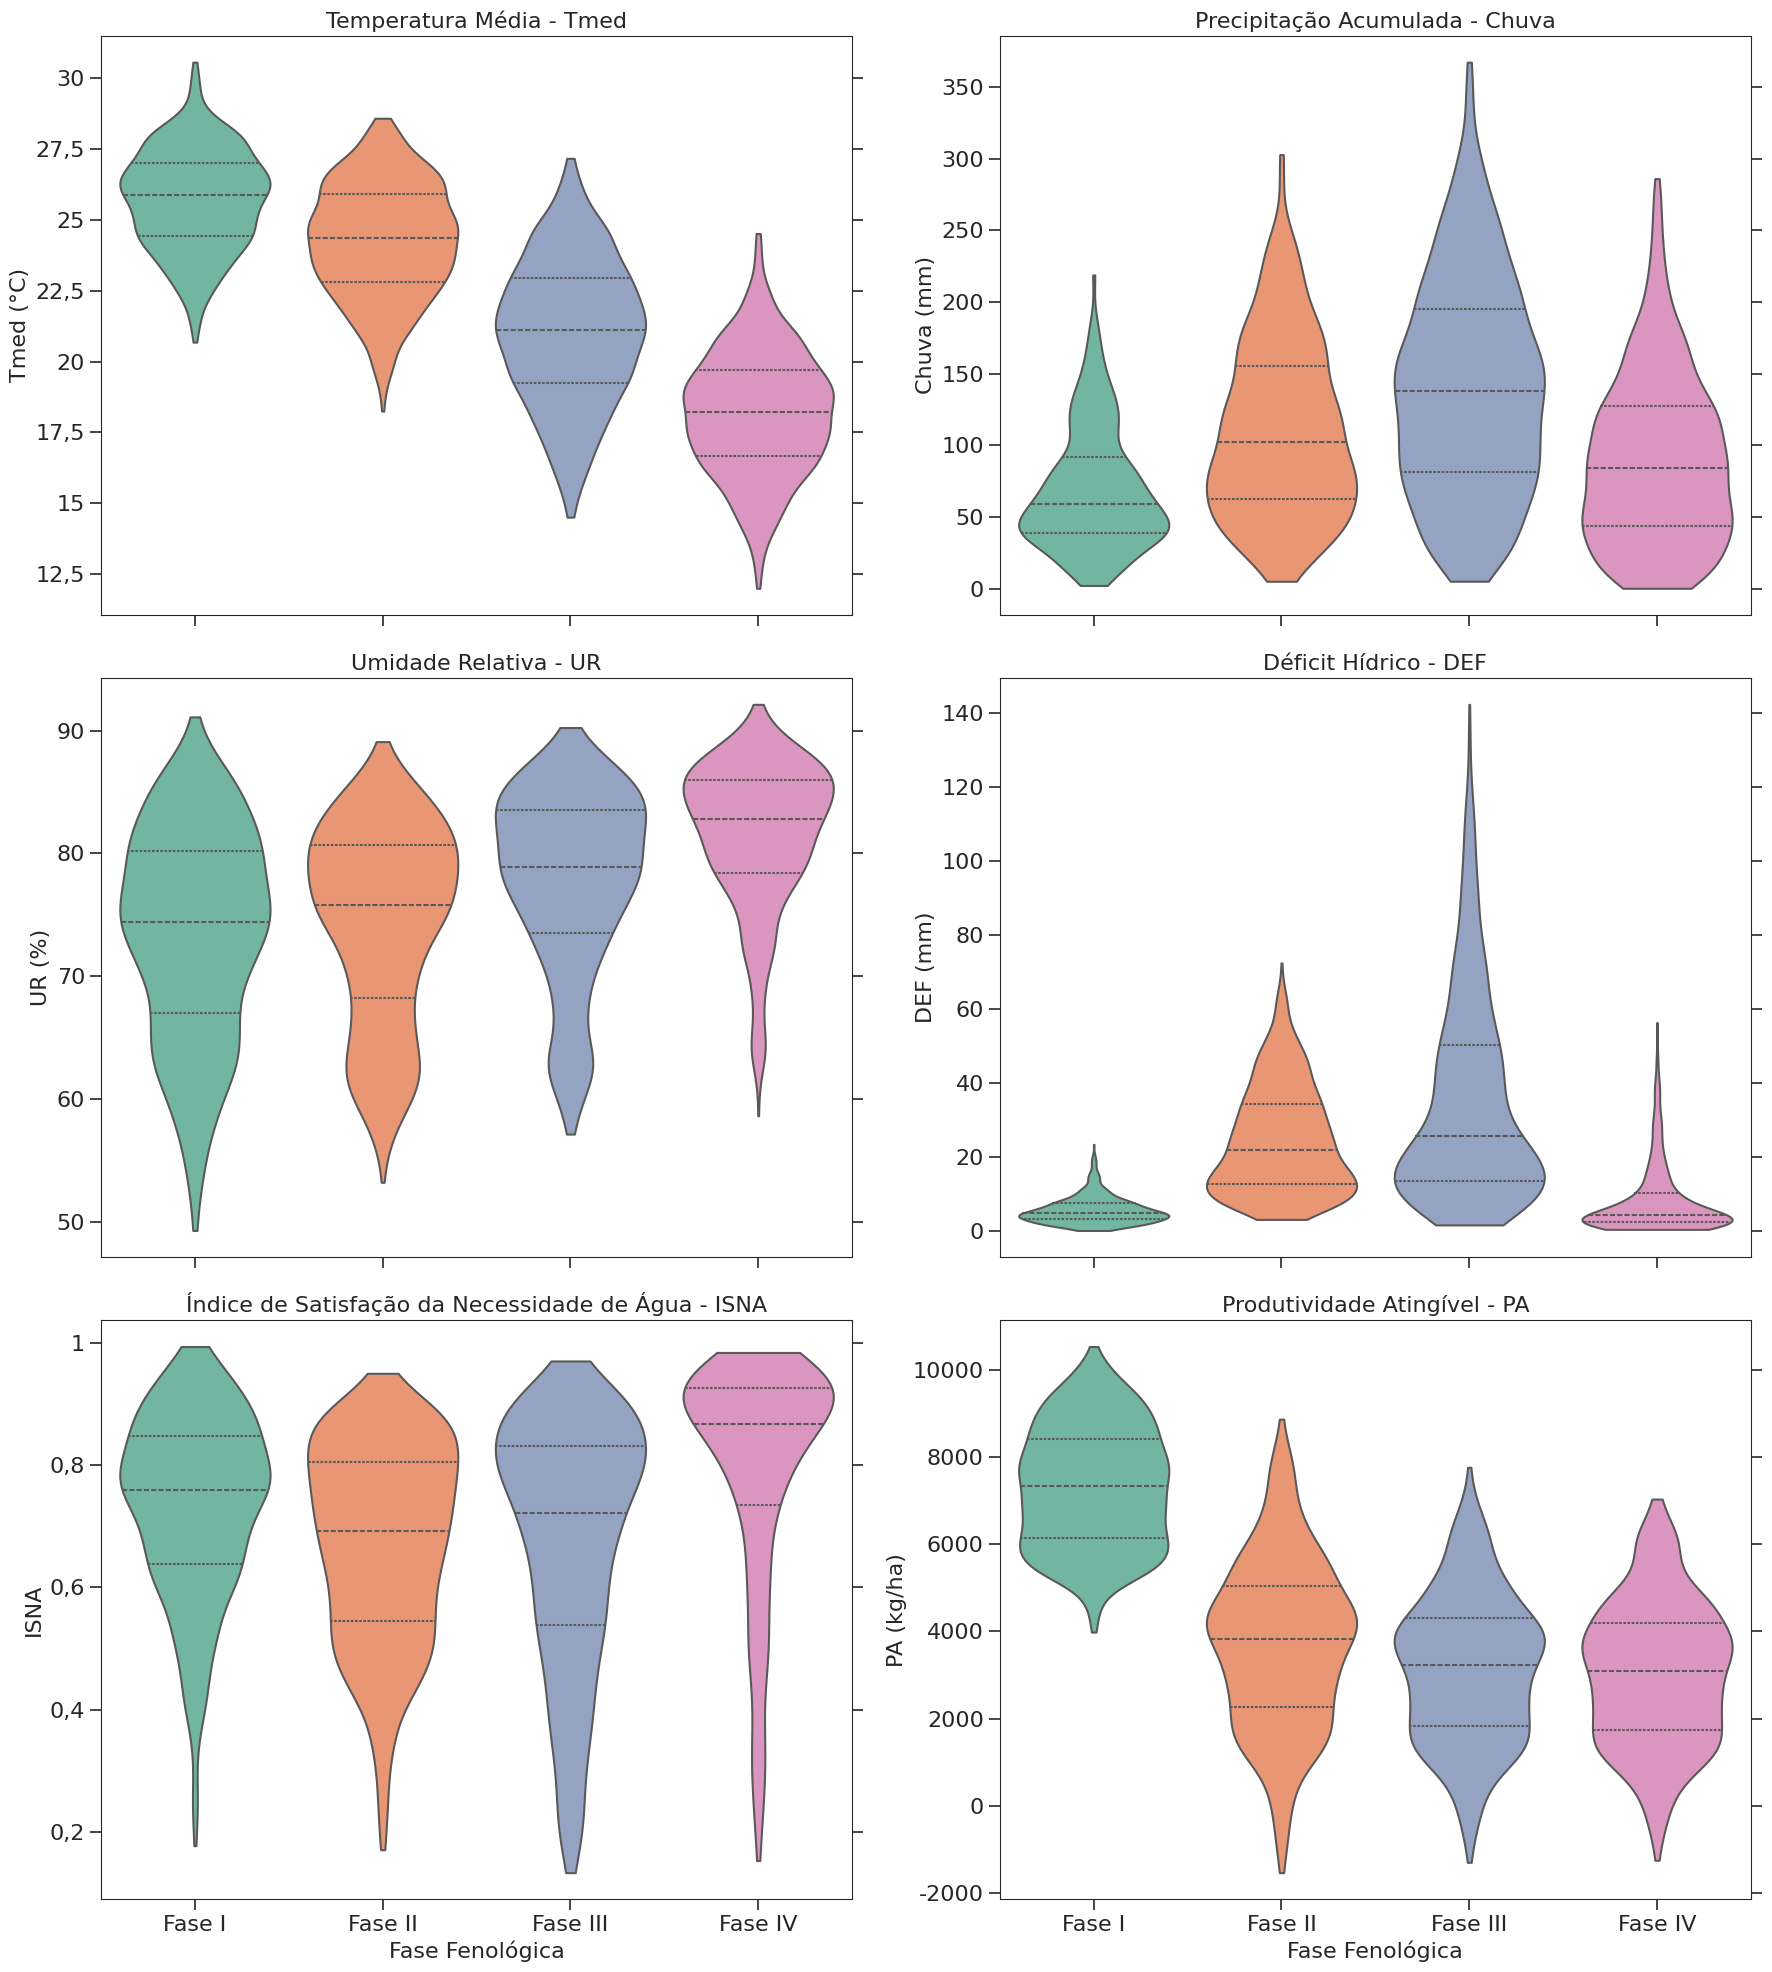

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# =========================================================
# 1. CONFIGURAÇÃO DE ESTILO (Fonte 16, sem negrito)
# =========================================================
sns.set_style("ticks")

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'axes.labelweight': 'normal'
})

# =========================================================
# 2. PREPARAÇÃO DOS DADOS
# =========================================================
df_plot = df.copy()

# Mapeamento dos nomes das fases
mapa_fases = {
    '1': 'Fase I',
    '2': 'Fase II',
    '3': 'Fase III',
    '4': 'Fase IV'
}
df_plot['Fase'] = df_plot['Fase'].astype(str).map(mapa_fases)

# Definição dos 6 painéis (3x2)
panels = [
    ("Tmed", "Temperatura Média - Tmed", "Tmed (°C)"),
    ("Chuva", "Precipitação Acumulada - Chuva", "Chuva (mm)"),
    ("UR", "Umidade Relativa - UR", "UR (%)"),
    ("DEF", "Déficit Hídrico - DEF", "DEF (mm)"),
    ("ISNA", "Índice de Satisfação da Necessidade de Água - ISNA", "ISNA"),
    ("PA", "Produtividade Atingível - PA", "PA (kg/ha)")
]

# Conversão e limpeza
for var, _, _ in panels:
    if df_plot[var].dtype == 'object':
        df_plot[var] = df_plot[var].str.replace(',', '.').astype(float)

# =========================================================
# 3. CRIAÇÃO DO MULTIPLOT (3x2)
# =========================================================
fig, axes = plt.subplots(3, 2, figsize=(18, 20))
axes = axes.flatten()

palette = "Set2"

for i, (var, title, ylabel) in enumerate(panels):
    ax = axes[i]

    sns.violinplot(
        ax=ax,
        data=df_plot,
        x='Fase',
        y=var,
        hue='Fase',
        palette=palette,
        inner="quartile",
        cut=0,
        linewidth=1.5,
        legend=False,
        order=list(mapa_fases.values())
    )

    ax.set_title(title)
    ax.set_ylabel(ylabel)

    # Formatação com vírgula no eixo Y
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{x:g}'.replace('.', ',')))

    # Labels de X apenas na última linha
    if i < 4:
        ax.set_xlabel("")
        ax.set_xticklabels([])
    else:
        ax.set_xlabel("Fase Fenológica")

    # Configuração dos Ticks
    ax.tick_params(axis='both', which='both', direction='out', length=8, width=1.2,
                   bottom=True, top=False, left=True, right=True)

plt.tight_layout()
plt.show()

In [5]:
import pandas as pd

# 1. Preparação dos dados (Garantindo que são números)
df_analise = df.copy()
vars_estudo = ['Tmed', 'Chuva', 'UR', 'DEF', 'ISNA', 'PA']

for col in vars_estudo:
    if df_analise[col].dtype == 'object':
        df_analise[col] = df_analise[col].str.replace(',', '.').astype(float)

# 2. Criando o DataFrame de Resumo Estatístico
# Agrupamos por Fase e calculamos várias métricas ao mesmo tempo
df_resumo = df_analise.groupby('Fase')[vars_estudo].agg([
    'mean',   # Média
    'std',    # Desvio Padrão (Variabilidade)
    'min',    # Valor Mínimo (Pior caso)
    'max',    # Valor Máximo (Melhor caso)
    'median'  # Mediana
]).reset_index()

# 3. Organizando os nomes das colunas para facilitar a leitura
# Isso transforma ('Chuva', 'mean') em 'Chuva_Media'
df_resumo.columns = [f"{col}_{stat}" if stat else col for col, stat in df_resumo.columns]

# Traduzindo sufixos para português (opcional)
mapa_colunas = {
    'mean': 'Media',
    'std': 'Desvio_Padrao',
    'min': 'Min',
    'max': 'Max',
    'median': 'Mediana'
}
df_resumo.columns = [col.replace('mean', 'Media').replace('std', 'Desvio_Padrao') for col in df_resumo.columns]

# 4. Exibindo o resultado formatado com vírgula (estilo BR)
# Nota: O pandas internamente usa ponto, aqui apenas formatamos a exibição
pd.options.display.float_format = '{:,.2f}'.format

print("--- Resumo Estatístico do Balanço Hídrico por Fase ---")
display(df_resumo)

# 5. Exportando para Excel ou CSV para você abrir no seu computador
df_resumo.to_excel("analise_estatistica_bh.xlsx", index=False)


--- Resumo Estatístico do Balanço Hídrico por Fase ---


,Fase,Tmed_Media,Tmed_Desvio_Padrao,Tmed_min,Tmed_max,Tmed_median,Chuva_Media,Chuva_Desvio_Padrao,Chuva_min,Chuva_max,...,ISNA_Media,ISNA_Desvio_Padrao,ISNA_min,ISNA_max,ISNA_median,PA_Media,PA_Desvio_Padrao,PA_min,PA_max,PA_median
0,1,25.72,1.78,20.68,30.57,25.88,69.65,41.93,2.40,218.97,...,0.73,0.15,0.18,0.99,0.76,"7,335.05","1,372.68","3,987.29","10,542.96","7,339.17"
1,2,24.27,2.02,18.25,28.59,24.37,111.49,61.38,5.31,302.83,...,0.67,0.16,0.17,0.95,0.69,"3,729.39","1,927.22","-1,537.79","8,875.09","3,833.27"
2,3,21.06,2.55,14.51,27.17,21.13,140.79,75.27,5.34,367.28,...,0.67,0.20,0.13,0.97,0.72,"3,160.44","1,697.15","-1,299.83","7,770.25","3,234.96"
3,4,18.18,2.17,12.00,24.52,18.22,90.09,59.11,0.42,286.07,...,0.79,0.19,0.15,0.98,0.87,"3,037.15","1,647.25","-1,252.85","7,040.30","3,095.41"
